### Case Study-  Personal Loan Acceptance Probability Calculations
The file `UniversalBank.csv` contains data on 5,000 customers of Universal Bank. The data include customer demographic information (age, income, etc.), the customer's relationship with the bank (mortgage, securities account, etc.), and the customer response to the last personal loan campaign (**Personal Loan**). Among these 5,000 customers, only 480 (~9.6%) accepted the personal loan that was offered to them in the earlier campaign.

In this exercise, we focus on two predictors:
* **Online**: Whether or not the customer is an active user of online banking services.
* **Credit Card** (abbreviated as **CC**): Whether the customer holds a credit card issued by the bank.
* **Personal Loan** (abbreviated as **Loan**): The target outcome variable.

---

In [57]:
# install the book's module to load the datasets
# !pip install dmba

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import dmba

In [59]:
df = dmba.load_data('UniversalBank.csv')
print(df.shape)

(5000, 14)


In [60]:
df.head(100)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,38,12,48,95617,4,0.2,3,0,0,0,0,1,0
96,97,41,15,80,95014,1,5.2,1,0,0,0,0,0,0
97,98,54,28,161,92121,1,2.9,1,0,0,0,0,1,0
98,99,49,23,94,92374,1,0.3,1,0,0,0,0,1,0




### Assignment Steps

**Partition the data into training (60%) and validation (40%) sets.**

* **a.** Create a pivot table for the training data with `Online` as a column variable, `CC` as a row variable, and `Loan` as a secondary row variable. The values inside the table should convey the count.



In [61]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.4, random_state=42)

print(f"Training set size: {len(df_train)} records")
print(f"Validation set size: {len(df_test)} records")

Training set size: 3000 records
Validation set size: 2000 records


**Check the distribution**

In [62]:
print(df["Personal Loan"].sum())

print(df["Personal Loan"].mean()*100)

480
9.6


* **b.** Consider the task of classifying a customer who owns a bank credit card and is actively using online banking services. Looking at the pivot table, what is the probability that this customer will accept the loan offer?
  > *Note: This is the probability of loan acceptance ($Loan = 1$) conditional on having a bank credit card ($CC = 1$) and being an active user of online banking services ($Online = 1$).*

In [7]:
df.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='str')

In [8]:
pd.pivot_table(data = df_train, index = "Online", columns = "CreditCard", values = "Personal Loan", aggfunc= "count", margins= True)

CreditCard,0,1,All
Online,,,
0,850,353,1203
1,1270,527,1797
All,2120,880,3000


In [9]:
pd.pivot_table(data = df_train, index = "Online", columns = "CreditCard", values = "Personal Loan", aggfunc= "count", margins= True)

CreditCard,0,1,All
Online,,,
0,850,353,1203
1,1270,527,1797
All,2120,880,3000


## Conditional Probability

In [10]:
df_train["Personal Loan"].mean()*100

np.float64(9.3)

In [11]:
df_train["Personal Loan"].sum()

np.int64(279)

In [12]:
pd.pivot_table(data = df_train, index = "Online", columns = "CreditCard", values = "Personal Loan", aggfunc= "sum", margins= True)

CreditCard,0,1,All
Online,,,
0,70,34,104
1,129,46,175
All,199,80,279


In [13]:
pd.pivot_table(data = df_train, index = "Online", columns = "CreditCard", values = "Personal Loan", aggfunc= "mean", margins= True).round(4)*100

CreditCard,0,1,All
Online,,,
0,8.24,9.63,8.65
1,10.16,8.73,9.74
All,9.39,9.09,9.30


* **c.** Create two separate pivot tables for the training data. One will have `Loan` (rows) as a function of `Online` (columns) and the other will have `Loan` (rows) as a function of `CC`.


In [14]:
pd.pivot_table(data = df_train, index = "Personal Loan", columns = "Online", values = "CreditCard", aggfunc= "sum", margins= True)

Online,0,1,All
Personal Loan,,,
0,319,481,800
1,34,46,80
All,353,527,880


In [15]:
pd.pivot_table(data = df_train, index = "Personal Loan", columns = "Online", values = "CreditCard", aggfunc= "mean", margins= True)

Online,0,1,All
Personal Loan,,,
0,0.290264,0.296547,0.294010
1,0.326923,0.262857,0.286738
All,0.293433,0.293267,0.293333


In [16]:
df_train["CreditCard"].sum()

np.int64(880)

In [17]:
pd.pivot_table(data = df_train, index = "Personal Loan", columns = "CreditCard", values = "Online", aggfunc= "sum", margins= True)

CreditCard,0,1,All
Personal Loan,,,
0,1141,481,1622
1,129,46,175
All,1270,527,1797


In [46]:
mask_CC = df['CreditCard']==1
mask_CC.index

RangeIndex(start=0, stop=5000, step=1)

## Using the pivot table the probability of a customer getting a Personal loan if they have CreditCard AND Online is 46/527=0.0873→8.73%

## Calculate the different ratios

In [18]:
# Total customers with CreditCard = 1
total_creditcard_1 = df_train.query("CreditCard == 1").shape[0]
print(f"Total customers with CreditCard = 1: {total_creditcard_1}")

# Customers with Personal Loan = 1 and CreditCard = 1
loan_1_creditcard_1 = df_train.query("`Personal Loan` == 1 & CreditCard == 1").shape[0]
print(f"Customers with Personal Loan = 1 and CreditCard = 1: {loan_1_creditcard_1}")

# Customers with Personal Loan = 0 and CreditCard = 1
loan_0_creditcard_1 = df_train.query("`Personal Loan` == 0 & CreditCard == 1").shape[0]
print(f"Customers with Personal Loan = 0 and CreditCard = 1: {loan_0_creditcard_1}")

# Customers with Personal Loan = 1 and Online = 1
loan_1_online_1 = df_train.query("`Personal Loan` == 1 & Online == 1").shape[0]
print(f"Customers with Personal Loan = 1 and Online = 1: {loan_1_online_1}")

# Customers with Personal Loan = 0 and Online = 1
loan_0_online_1 = df_train.query("`Personal Loan` == 0 & Online == 1").shape[0]
print(f"Customers with Personal Loan = 0 and Online = 1: {loan_0_online_1}")

# Total customers with Personal Loan = 1
total_loan_1 = df_train.query("`Personal Loan` == 1").shape[0]
print(f"Total customers with Personal Loan = 1: {total_loan_1}")

# Total customers with Personal Loan = 0
total_loan_0 = df_train.query("`Personal Loan` == 0").shape[0]
print(f"Total customers with Personal Loan = 0: {total_loan_0}")

Total customers with CreditCard = 1: 880
Customers with Personal Loan = 1 and CreditCard = 1: 80
Customers with Personal Loan = 0 and CreditCard = 1: 800
Customers with Personal Loan = 1 and Online = 1: 175
Customers with Personal Loan = 0 and Online = 1: 1622
Total customers with Personal Loan = 1: 279
Total customers with Personal Loan = 0: 2721


* **d.** Compute the following quantities ($P(A \mid B)$ means "the probability of $A$ given $B$"):
  * **i.** $P(CC = 1 \mid Loan = 1)$ (the proportion of credit card holders among the loan acceptors)
  * **ii.** $P(Online = 1 \mid Loan = 1)$
  * **iii.** $P(Loan = 1)$ (the proportion of loan acceptors)
  * **iv.** $P(CC = 1 \mid Loan = 0)$
  * **v.** $P(Online = 1 \mid Loan = 0)$
  * **vi.** $P(Loan = 0)$


In [19]:
# P(CC=1∣Loan=1)
80/279

0.2867383512544803

In [20]:
# 2nd part
175/279

0.6272401433691757

In [21]:
df_train["Personal Loan"].mean()

np.float64(0.093)

In [22]:
# P(CC=1∣Loan=0)
800/2721

0.29400955531054757

In [23]:
# P(Online=1∣Loan=0)
1622/2721

0.5961043733921353

In [24]:
1- df_train["Personal Loan"].mean()

np.float64(0.907)

(CC= 1 & Loan = 1 & online = 1) / (cc = 1 & online = 1)

* **e.** Use the quantities computed above to compute the naive Bayes probability $P(Loan = 1 \mid CC = 1, Online = 1)$.


## Naive Bayes calculations

We want to calculate:

$$
P(\text{Loan}=1 \mid \text{CreditCard}=1,\ \text{Online}=1)
$$

Using Naive Calculation:

$$
P(Y \mid X_1, X_2)
=
\frac{
P(X_1 \mid Y)\times P(X_2 \mid Y)\times P(Y)
}{
P(X_1, X_2)
}
$$

Substituting our variables:

$$
P(\text{Loan}=1 \mid \text{CreditCard}=1,\ \text{Online}=1)
=
\frac{
P(\text{CreditCard}=1 \mid \text{Loan}=1)
\times
P(\text{Online}=1 \mid \text{Loan}=1)
\times
P(\text{Loan}=1)
}{
P(\text{CreditCard}=1,\ \text{Online}=1)
}
$$

Naive Bayes assumes that the features are conditionally independent:

$$
P(X_1, X_2 \mid Y)
=
P(X_1 \mid Y)\times P(X_2 \mid Y)
$$

Therefore:

$$
P(\text{CreditCard},\text{Online} \mid \text{Loan})
=
P(\text{CreditCard} \mid \text{Loan})
\times
P(\text{Online} \mid \text{Loan})
$$

In [25]:
# P(CC=1 | Loan=1)
p_cc_given_loan = (df_train.query("`Personal Loan` == 1 and CreditCard == 1").shape[0]/
                  df_train.query("`Personal Loan` == 1").shape[0]
                  )

# P(Online=1 | Loan=1)
p_online_given_loan = (df_train.query("`Personal Loan` == 1 and Online == 1").shape[0]   /
                        df_train.query("`Personal Loan` == 1").shape[0]
                      )

# P(Loan=1)
p_loan = df_train["Personal Loan"].mean()

# P(CC=1 and Online=1)
p_cc_online = (df_train.query("CreditCard == 1 and Online == 1").shape[0] /
                len(df_train)
                )

# Naive Bayes probability
nb_prob = ( p_cc_given_loan * p_online_given_loan * p_loan
          ) / p_cc_online

print(nb_prob)

0.09521672005604184


## Using the pivot table the probability of a customer getting a Personal loan if they have CreditCard AND Online is 0.0952→9.52%

* **f.** Compare this value with the one obtained from the pivot table in **(b)**. Which is a more accurate estimate?

* In Python, run naive Bayes on the data. Examine the model output on training data, and find the entry that corresponds to $P(Loan = 1 \mid CC = 1, Online = 1)$. Compare this to the number you obtained in **(e)**.

## Sklearn Naive Bayes Overview

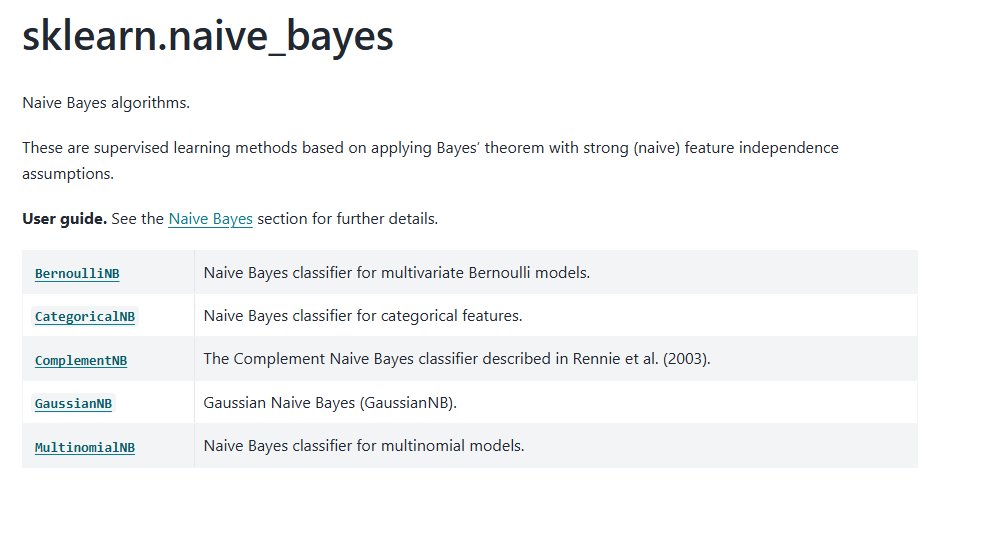

| Model | Feature Assumption | Think of Feature As | Best Used For | Advantages | Disadvantages |
|---|---|---|---|---|---|
| BernoulliNB | Binary features (`0/1`) | Did the event happen or not? | Spam detection using word presence | Simple, fast, good for binary data | Poor for continuous or count data |
| CategoricalNB | Categorical/discrete features | Which category does it belong to? | Encoded categorical variables | Naturally handles categorical data | Requires proper categorical encoding |
| ComplementNB | Count/frequency data (improved MultinomialNB) | Frequency with imbalance handling | Imbalanced text classification | Better for imbalanced datasets | Mostly useful for text/count problems |
| GaussianNB | Gaussian (normal) distribution | Continuous numeric value | Numerical continuous features like age, salary | Very fast, works well on small datasets | Assumption of normality may fail |
| MultinomialNB | Count/frequency features | How many times did it happen? | NLP, document classification, word counts | Excellent for text classification | Poor for continuous/negative values |

#### Naive Bayes Models

In [26]:
# NB using Sklearn

from sklearn.naive_bayes import CategoricalNB

clf = CategoricalNB(alpha = 0)

clf.fit(df_train[["Online", "CreditCard"]], df_train["Personal Loan"])

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[1099....104., 175.]]), array([[1921....199., 80.]])]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[2721., 279.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.1 ,-2.38]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-0.90...-0.46642581]]), array([[-0.34...-1.24918515]])]"


In [56]:
clf.predict(df_train[["Online", "CreditCard"]])

array([0, 0, 0, ..., 0, 0, 0], shape=(3000,))

In [28]:
df_train["cat_predictions"] = clf.predict(df_train[["Online", "CreditCard"]])

In [29]:
from sklearn.naive_bayes import BernoulliNB
bnl = BernoulliNB()

bnl.fit(df_train[["Online", "CreditCard"]], df_train["Personal Loan"])

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[2721., 279.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.1 ,-2.38]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 2)","[[1622., 800.], [ 175., 80.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 2)","[[-0.52,-1.22], [-0.47,-1.24]]"


In [30]:
df_train["bnl_predictions"] = bnl.predict(df_train[["Online", "CreditCard"]])

In [31]:
df_train[["Personal Loan", "cat_predictions", "bnl_predictions"]].sum()

Personal Loan      279
cat_predictions      0
bnl_predictions      0
dtype: int64

#### Logistic Regression Model

In [32]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=0)

lr.fit(df_train[["Online", "CreditCard"]], df_train["Personal Loan"])

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver

In [33]:
df_train["lr_predictions"] = lr.predict(df_train[["Online", "CreditCard"]])

In [34]:
df_train[["Personal Loan", "cat_predictions", "bnl_predictions", "lr_predictions"]].sum()

Personal Loan      279
cat_predictions      0
bnl_predictions      0
lr_predictions       0
dtype: int64

#### Random Forest Model

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state = 0, max_depth = 4)

rf.fit(df_train[["Online", "CreditCard"]], df_train["Personal Loan"])

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: 

In [36]:
df_train["rf_predictions"] = rf.predict(df_train[["Online", "CreditCard"]])

In [37]:
df_train.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard,cat_predictions,bnl_predictions,lr_predictions,rf_predictions
4576,4577,55,30,41,93003,2,0.6,3,0,0,0,0,1,1,0,0,0,0
1088,1089,59,35,95,95521,1,3.8,1,0,0,0,0,1,1,0,0,0,0
479,480,60,36,132,92154,2,6.0,1,470,0,0,0,1,1,0,0,0,0
727,728,62,37,18,92037,3,1.3,2,0,0,0,0,1,0,0,0,0,0
3783,3784,60,34,51,90028,3,1.4,3,0,0,0,0,0,0,0,0,0,0


## Comparison across model predictions

In [38]:
df_train[["Personal Loan", "cat_predictions", "bnl_predictions", "lr_predictions", "rf_predictions"]].sum()

Personal Loan      279
cat_predictions      0
bnl_predictions      0
lr_predictions       0
rf_predictions       0
dtype: int64

In [39]:
1-(279/3000)

0.907

In [50]:
df_train['Personal Loan'].value_counts()

Personal Loan
0    2721
1     279
Name: count, dtype: int64